In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import math
from statistics import *

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization
from keras.layers import LSTM

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from pandas.api.types import CategoricalDtype

from category_encoders import MEstimateEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from tensorflow.keras import callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
data=pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
test=pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
print(data.shape)
print(test.shape)

(1460, 81)
(1459, 80)


# Visualization

/opt/conda/lib/python3.7/site-packages/seaborn/distributions.py:2557: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='SalePrice', ylabel='Density'>

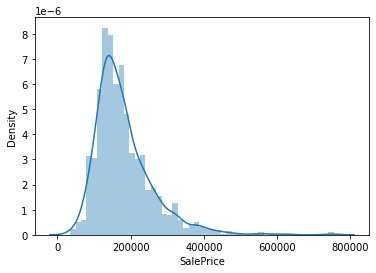

In [3]:
sns.distplot(data['SalePrice'])

<AxesSubplot:>

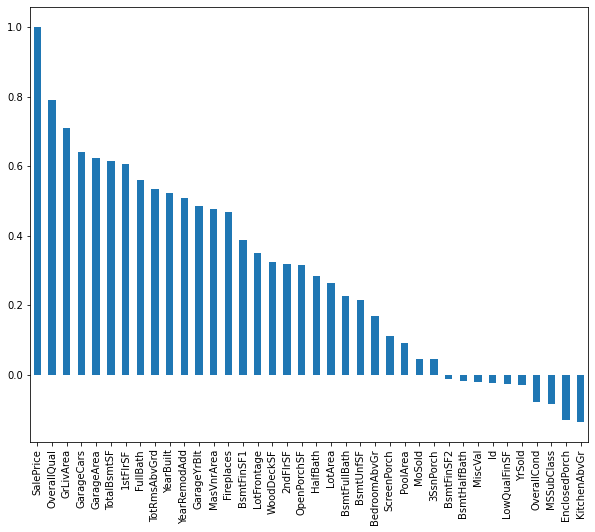

In [4]:
plt.figure(figsize=(10,8))
data.corr()['SalePrice'].sort_values(ascending=False).plot(kind='bar')

<AxesSubplot:xlabel='SalePrice', ylabel='GrLivArea'>

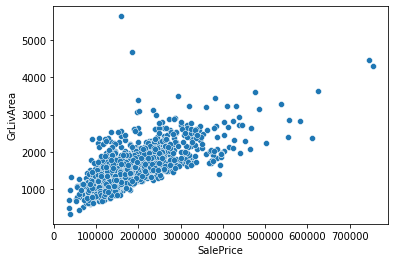

In [5]:
  sns.scatterplot(x='SalePrice', y='GrLivArea',data=data)

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='LotShape', ylabel='count'>

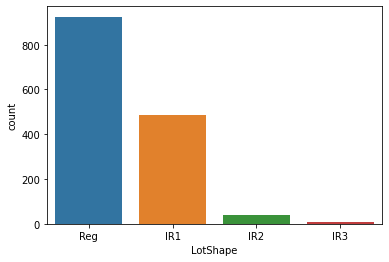

In [6]:
sns.countplot(data['LotShape'])

/opt/conda/lib/python3.7/site-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='PoolArea', ylabel='count'>

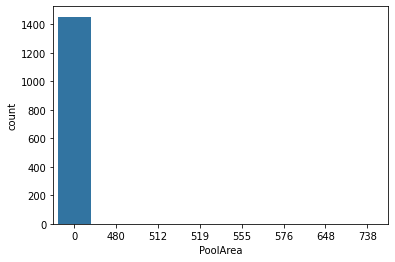

In [7]:
sns.countplot(data['PoolArea'])

In [8]:
data.corr()['SalePrice'][abs(data.corr()['SalePrice'])>0.3].sort_values()

OpenPorchSF     0.315856
2ndFlrSF        0.319334
WoodDeckSF      0.324413
LotFrontage     0.351799
BsmtFinSF1      0.386420
Fireplaces      0.466929
MasVnrArea      0.477493
GarageYrBlt     0.486362
YearRemodAdd    0.507101
YearBuilt       0.522897
TotRmsAbvGrd    0.533723
FullBath        0.560664
1stFlrSF        0.605852
TotalBsmtSF     0.613581
GarageArea      0.623431
GarageCars      0.640409
GrLivArea       0.708624
OverallQual     0.790982
SalePrice       1.000000
Name: SalePrice, dtype: float64

# Missing Values

In [9]:
data.isnull().sum()[data.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [10]:
data.drop(['Id','FireplaceQu','Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)
test.drop(['Id','FireplaceQu','Alley','PoolQC','Fence','MiscFeature'],axis=1,inplace=True)

In [11]:
num_cols = data._get_numeric_data().columns
cols=data.columns
features_cat = list(set(cols) - set(num_cols))
features_num = list(num_cols)
features_num.remove('SalePrice')

In [12]:
for i in features_cat:
    data[i] = data[i].fillna(data[i].mode()[0])
    test[i] = test[i].fillna(test[i].mode()[0])
for i in features_num:
    data[i] = data[i].fillna(data[i].mean())
    test[i] = test[i].fillna(test[i].mode()[0])
data.isnull().sum()[data.isnull().sum()>0]

Series([], dtype: int64)

# Preprocessing

In [13]:
import copy
X=data.drop('SalePrice',axis=1)
y=data['SalePrice']

In [14]:
for colname in X.select_dtypes(["object", "category"]):
        X[colname], _ = X[colname].factorize()
    
discrete_features = [pd.api.types.is_integer_dtype(t) for t in X.dtypes]
mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features, random_state=0)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)
mi_scores


OverallQual     5.786503e-01
Neighborhood    5.253900e-01
GarageArea      4.927946e-01
GrLivArea       4.328080e-01
YearBuilt       4.087151e-01
                    ...     
Street          3.666896e-04
Utilities       1.887379e-15
PoolArea        2.220446e-16
MiscVal         0.000000e+00
MoSold          0.000000e+00
Name: MI Scores, Length: 74, dtype: float64

In [15]:
print(X.shape)
train_objs_num = len(X)
dataset = pd.concat(objs=[X, test], axis=0)
l=dataset.select_dtypes(['object']).columns
dummies = pd.get_dummies(dataset[l],drop_first=True)
#dataset = pd.get_dummies(dataset)
dataset = dataset.drop(l,axis=1)
dataset = pd.concat([dataset,dummies],axis=1)

(1460, 74)


In [16]:
dataset["LivLotRatio"] = data.GrLivArea / data.LotArea
dataset["MedNhbdArea"] = data.groupby("Neighborhood")["GrLivArea"].transform("median")
features = [
    "LotArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "GrLivArea",
]

In [17]:
print(dataset.shape)
dataset.isnull().sum()[dataset.isnull().sum()>0]

(2919, 452)


Series([], dtype: int64)

In [18]:
dataset["Feature1"] = dataset.GrLivArea + dataset.TotalBsmtSF
dataset["Feature2"] = dataset.YearRemodAdd * dataset.TotalBsmtSF

In [19]:
X = copy.copy(dataset[:train_objs_num])
test = copy.copy(dataset[train_objs_num:])

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8)

In [21]:
s=StandardScaler()
X_train1 = s.fit_transform(X_train)
X_valid1 = s.transform(X_valid)
test1 = s.transform(test)

# XGB

In [22]:
xgb_params = dict(
    max_depth=7,           # maximum depth of each tree - try 2 to 10
    learning_rate=0.05,    # effect of each tree - try 0.0001 to 0.1
    n_estimators=1000,     # number of trees (that is, boosting rounds) - try 1000 to 8000
    min_child_weight=4,    # minimum number of houses in a leaf - try 1 to 10
    colsample_bytree=0.7,  # fraction of features (columns) per tree - try 0.2 to 1.0
    subsample=0.7,         # fraction of instances (rows) per tree - try 0.2 to 1.0
    reg_alpha=0.5,         # L1 regularization (like LASSO) - try 0.0 to 10.0
    reg_lambda=1.0,        # L2 regularization (like Ridge) - try 0.0 to 10.0
    num_parallel_tree=1,   #  > 1 for boosted rf
)

model1 = XGBRegressor(**xgb_params)
model1.fit(X_train1,y_train)
preds1=model1.predict(X_valid1)
print(model1.score(X_valid1,y_valid))
print('MAE',mean_absolute_error(y_valid, preds1))

0.9151845788859744
MAE 15514.430490154109


/opt/conda/lib/python3.7/site-packages/xgboost/data.py:114: UserWarning: Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption
  "because it will generate extra copies and increase " +


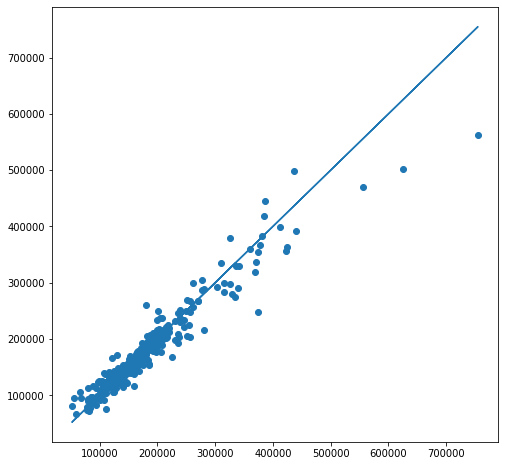

In [23]:
plt.figure(figsize=(8,8))
plt.scatter(y_valid,preds1)
plt.plot(y_valid,y_valid)

In [24]:
model1.fit(X, np.log(y))
predictions = np.exp(model1.predict(test1))

/opt/conda/lib/python3.7/site-packages/xgboost/data.py:114: UserWarning: Use subset (sliced data) of np.ndarray is not recommended because it will generate extra copies and increase memory consumption
  "because it will generate extra copies and increase " +


# PCA features

In [25]:
from sklearn.decomposition import PCA
pca=PCA(n_components=4)
pca.fit(X_train)
x_train_pca = pca.transform(X_train)
x_val_pca=pca.transform(X_valid)
component_names = [f"PC{i+1}" for i in range(x_train_pca.shape[1])]
x_train_pca = pd.DataFrame(x_train_pca, columns=component_names)
x_train_pca

,PC1,PC2,PC3,PC4
0,-2.095549e+06,2274.362966,500.006323,23.061753
1,-7.851564e+05,-2260.922668,13.139654,259.404397
2,-2.235586e+05,-3783.409160,-702.493542,-184.375125
3,7.841994e+05,-1700.211372,-582.606310,259.541090
4,-3.917246e+05,6189.483158,-956.465455,-98.362010
...,...,...,...,...
1163,-4.573008e+05,632.377249,687.786190,191.902735
1164,-2.841719e+05,36009.613632,993.176886,-475.079043
1165,9.064381e+05,-916.448117,-433.984041,-77.930924
1166,-5.796417e+05,-1654.133558,518.613725,56.335518


In [26]:
component_names = [f"PC{i+1}" for i in range(x_val_pca.shape[1])]
x_val_pca = pd.DataFrame(x_val_pca, columns=component_names)
x_val_pca

,PC1,PC2,PC3,PC4
0,3.123953e+05,15003.911034,1303.539877,243.971644
1,-4.859322e+05,3161.892403,909.373066,262.267291
2,-4.515141e+05,988.131166,587.984913,-113.132888
3,7.315679e+05,665.539810,-297.017321,396.421218
4,2.444544e+05,302.385757,-545.451785,-454.472010
...,...,...,...,...
287,1.127132e+06,-2672.028956,-26.130972,-16.290810
288,-7.953568e+04,4410.513230,-525.992562,1859.721713
289,-3.390701e+05,-704.856692,641.629104,-242.476911
290,1.495621e+06,-2516.968151,-277.683191,429.655299


In [27]:
from sklearn.feature_selection import mutual_info_regression
def score_pca(df,dt):
    mi_scores = mutual_info_regression(df, dt, random_state=0)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=df.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [28]:
mi_scores=score_pca(x_train_pca,y_train)
g=pd.DataFrame(x_train_pca)[mi_scores.index[0]]
X_train['fet1']=list(g)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [29]:
mi_scores1=score_pca(x_val_pca,y_valid)
g=pd.DataFrame(x_val_pca)[mi_scores1.index[0]]
X_valid['fet1']=list(g)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [30]:
X_valid.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LivLotRatio,MedNhbdArea,Feature1,Feature2,fet1
692,60,42.0,26178,7,5,1989,1990,293.0,965.0,0.0,...,0,0,0,0,0,0.096226,1689.5,3729.0,2407900.0,312395.305993
391,60,71.0,12209,6,5,2001,2002,0.0,690.0,0.0,...,0,0,0,0,0,0.160619,1204.0,2765.0,1609608.0,-485932.157124
1293,60,78.0,10140,7,5,1976,1976,0.0,194.0,0.0,...,0,0,0,0,0,0.164103,1664.0,2496.0,1644032.0,-451514.054425
598,20,80.0,12984,5,6,1977,1977,459.0,1283.0,147.0,...,0,0,0,0,0,0.126848,1717.0,3077.0,2827110.0,731567.916747
154,30,84.0,11340,6,5,1923,1950,0.0,0.0,0.0,...,0,0,0,0,0,0.105820,1374.0,2400.0,2340000.0,244454.438581


In [31]:
s1=MinMaxScaler()
X_train2 = s1.fit_transform(X_train)
X_valid2 = s1.transform(X_valid)

# RF

In [32]:
model2 = RandomForestRegressor()
model2.fit(X_train1,y_train)
preds2=model2.predict(X_valid1)
print(model2.score(X_valid1,y_valid))
print('MAE',mean_absolute_error(y_valid, preds2))

0.8766827274942528
MAE 18067.373458904112


# NN

In [33]:
nn_model = Sequential()

nn_model.add(Dense(512,input_dim=X_train.shape[1], kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(256,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(128,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(64,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(32,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(8,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(8,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(8,kernel_initializer='normal', activation='relu'))
nn_model.add(Dense(1))
nn_model.compile(loss='mse', optimizer=Adam(lr=0.001))


early_stopping = EarlyStopping(
    min_delta=0.001, 
    patience=5, 
    restore_best_weights=True,
)

Epoch 1/100
19/19 [==============================] - 1s 40ms/step - loss: 41416747212.8000 - val_loss: 41583079424.0000
Epoch 2/100
19/19 [==============================] - 0s 7ms/step - loss: 39127018496.0000 - val_loss: 41582206976.0000
Epoch 3/100
19/19 [==============================] - 0s 7ms/step - loss: 39699740467.2000 - val_loss: 41525067776.0000
Epoch 4/100
19/19 [==============================] - 0s 7ms/step - loss: 38803428761.6000 - val_loss: 40130736128.0000
Epoch 5/100
19/19 [==============================] - 0s 8ms/step - loss: 34903400652.8000 - val_loss: 24430110720.0000
Epoch 6/100
19/19 [==============================] - 0s 8ms/step - loss: 14413184051.2000 - val_loss: 8005111296.0000
Epoch 7/100
19/19 [==============================] - 0s 8ms/step - loss: 6189233075.2000 - val_loss: 5999280128.0000
Epoch 8/100
19/19 [==============================] - 0s 8ms/step - loss: 4325460544.0000 - val_loss: 4864283648.0000
Epoch 9/100
19/19 [==============================] -

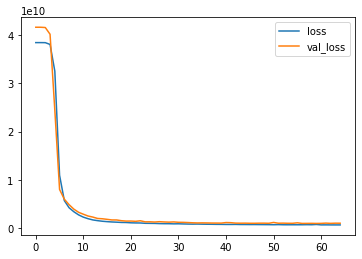

In [34]:
nn_model.fit(X_train2,y_train, validation_data=(X_valid2,y_valid), epochs=100, callbacks=[early_stopping], 
             batch_size=64, verbose=1)
loss=pd.DataFrame(nn_model.history.history)
loss.plot()
preds_nn=nn_model.predict(X_valid2)
print('MAE',mean_absolute_error(y_valid, preds_nn))
print('MSE',mean_squared_error(y_valid, preds_nn))